# Redes Neurais Artificiais MLP

In [1]:
import seaborn as sns

titanic = sns.load_dataset('titanic')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Cria-se um DataFrame, removendo linhas com valores ausentes do conjunto de dados do Titanic. Em seguida, separa as variáveis de entrada (características) e a variável de saída (survived) em, que indica se o passageiro sobreviveu ou não.

In [2]:
#criando dataframe
df = titanic.dropna()
# separa entrada e saída
entrada = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']]
saida = df['survived']

O LabelEncoder é utilizado para converter variáveis categóricas em valores numéricos. O resultado é armazenado em (entrada_encoded), que agora contém as mesmas características dos passageiros, mas em formato numérico, facilitando a aplicação de algoritmos de machine learning.

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
entrada_encoded = entrada.apply(label_encoder.fit_transform)
entrada_encoded

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,0,0,32,1,0,57,0,0,2,0,2,0,1,0
3,0,0,28,1,0,44,2,0,2,0,2,2,1,0
6,0,1,49,0,0,41,2,0,1,1,4,2,0,1
10,2,0,4,1,1,10,2,2,0,0,6,2,1,0
11,0,0,53,0,0,17,2,0,2,0,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,0,0,42,1,1,43,2,0,2,0,3,2,1,0
872,0,1,26,0,0,1,2,0,1,1,1,2,0,1
879,0,0,51,0,1,68,0,0,2,0,2,0,1,0
887,0,0,12,0,0,23,2,0,2,0,1,2,1,1


Em seguida é preciso dividir o conjunto de dados em conjuntos de treinamento e teste. A variável `entrada_encoded` (características dos passageiros) é separada em `X_train` (80% dos dados para treinamento) e `X_test` (20% dos dados para teste), enquanto `saida` (variável de saída, indicando sobrevivência) é dividida em `y_train` e `y_test`, respectivamente. Essa divisão é crucial para avaliar o desempenho do modelo e garantir que ele não se torne especialista nos dados de treinamento, permitindo uma validação adequada em dados não vistos.


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(entrada_encoded, saida, test_size=0.2)

Neste trecho de código, a função `to_categorical` é utilizada para converter as etiquetas da variável de saída  em uma representação binária. Isso é útil para tarefas de classificação em redes neurais, pois permite que o modelo interprete as classes de forma mais eficaz.

In [5]:
from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

Neste código, um modelo de rede neural sequencial é criado usando a biblioteca Keras. A rede é do tipo FeedForward, começando com uma camada de entrada que possui 10 neurônios e utiliza a função de ativação sigmoid, recebendo 14 entradas (características). Em seguida, há uma camada intermediária com 6 neurônios e também a função de ativação sigmoid. A camada de saída possui 2 neurônios e usa a função de ativação softmax, adequada para problemas de classificação multiclasse, pois produz probabilidades para cada classe.

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


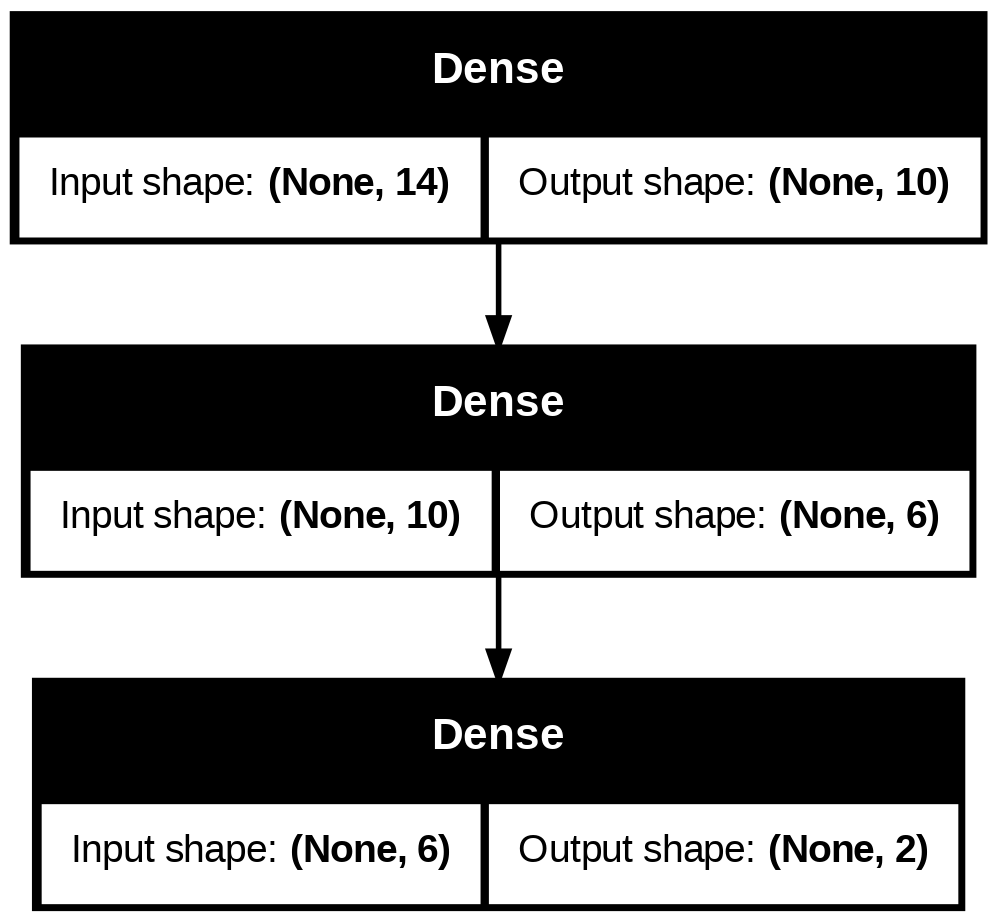

In [6]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import plot_model

rede = Sequential() # FeedForward
# camadas entradas
rede.add(Dense(10, activation='sigmoid', input_dim=14))
# camadas intermediarias
rede.add(Dense(6, activation='sigmoid'))
# camada de saida
rede.add(Dense(2, activation='softmax'))

plot_model(rede, to_file='model.png', show_shapes=True)

In [7]:
rede.compile('adam', loss='categorical_crossentropy',  metrics=['accuracy'] )

Em seguida, realiza-se o treinamento do modelo utilizando as entradas e saídas de treino separadas anteriormente.

In [8]:
treinamento = rede.fit(X_train, y_train, epochs=300, verbose=2)

Epoch 1/300
5/5 - 3s - 549ms/step - accuracy: 0.3034 - loss: 0.9274
Epoch 2/300
5/5 - 0s - 33ms/step - accuracy: 0.3034 - loss: 0.9071
Epoch 3/300
5/5 - 0s - 27ms/step - accuracy: 0.3034 - loss: 0.8890
Epoch 4/300
5/5 - 0s - 26ms/step - accuracy: 0.3034 - loss: 0.8707
Epoch 5/300
5/5 - 0s - 15ms/step - accuracy: 0.3034 - loss: 0.8525
Epoch 6/300
5/5 - 0s - 26ms/step - accuracy: 0.3034 - loss: 0.8356
Epoch 7/300
5/5 - 0s - 13ms/step - accuracy: 0.3034 - loss: 0.8196
Epoch 8/300
5/5 - 0s - 9ms/step - accuracy: 0.3034 - loss: 0.8043
Epoch 9/300
5/5 - 0s - 18ms/step - accuracy: 0.3034 - loss: 0.7897
Epoch 10/300
5/5 - 0s - 25ms/step - accuracy: 0.3034 - loss: 0.7748
Epoch 11/300
5/5 - 0s - 33ms/step - accuracy: 0.3034 - loss: 0.7606
Epoch 12/300
5/5 - 0s - 53ms/step - accuracy: 0.3034 - loss: 0.7472
Epoch 13/300
5/5 - 0s - 28ms/step - accuracy: 0.3241 - loss: 0.7338
Epoch 14/300
5/5 - 0s - 23ms/step - accuracy: 0.3379 - loss: 0.7215
Epoch 15/300
5/5 - 0s - 11ms/step - accuracy: 0.4069 - lo

O gráfico a seguir de Épocas x Acurácia permite visualizar o crescimento do desempenho da Rede Neural. Com o modelo treinado neste relatório, a rede alcançou 100% de acurácia em aproximadamente 250 épocas. Isso, no entanto, não é necessariamente bom, pois significa que, dadas as entradas fornecidas durante o treinamento, a rede sempre as classificará corretamente. Por esse motivo, é essencial testar com novos dados para evitar resultados falsamente positivos e garantir que a rede não esteja superajustada.

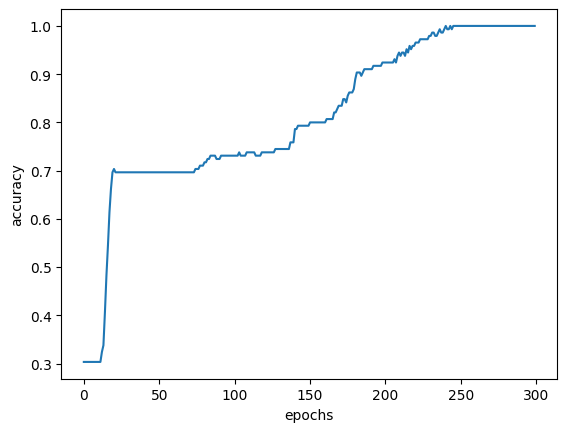

In [9]:
import matplotlib.pyplot as plt

plt.plot(treinamento.history['accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()


O gráfico de Épocas (Epochs) x Perda (Loss) mostra a evolução da função de perda durante o treinamento de um modelo, como uma rede neural. A "perda" (loss) é uma medida de quão bem o modelo está se ajustando aos dados, indicando o erro entre as previsões do modelo e os valores reais.

Text(0, 0.5, 'loss')

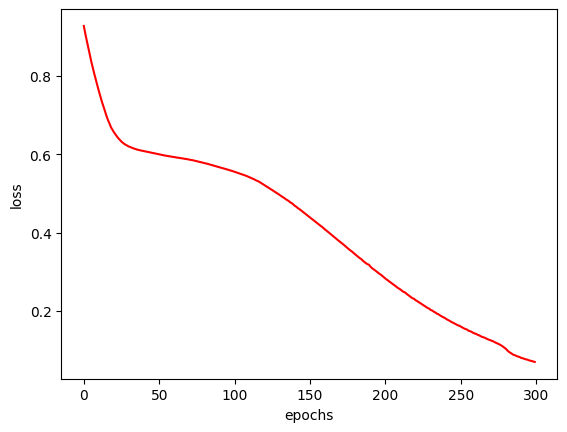

In [10]:
plt.plot(treinamento.history['loss'], c='red')
plt.xlabel('epochs')
plt.ylabel('loss')

A seguir, é realizada a predição (a probabilidade de o passageiro ter sobrevivido ou não), sendo que o primeiro valor indica a chance de sobrevivência, e o segundo, a de não ter sobrevivido.

In [11]:
predict = rede.predict(X_test)
print(predict)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.02371936 0.9762806 ]
 [0.97044146 0.02955844]
 [0.01792807 0.98207194]
 [0.01837733 0.98162276]
 [0.15244038 0.84755963]
 [0.89395344 0.10604659]
 [0.8459982  0.15400174]
 [0.0642314  0.9357686 ]
 [0.01855504 0.9814449 ]
 [0.9231373  0.07686262]
 [0.85799176 0.14200822]
 [0.8601008  0.13989922]
 [0.9308256  0.06917439]
 [0.8956521  0.10434783]
 [0.115748   0.884252  ]
 [0.12541206 0.8745879 ]
 [0.03777101 0.96222883]
 [0.0194523  0.98054767]
 [0.01916686 0.98083305]
 [0.02029515 0.97970486]
 [0.8849965  0.11500351]
 [0.90284085 0.0971591 ]
 [0.01943922 0.9805608 ]
 [0.01925228 0.9807477 ]
 [0.92570066 0.07429934]
 [0.02380175 0.9761982 ]
 [0.01954287 0.98045707]
 [0.0181192  0.9818808 ]
 [0.04156097 0.958439  ]
 [0.16324137 0.83675855]
 [0.12791136 0.8720886 ]
 [0.12088158 0.87911844]
 [0.02233232 0.9776677 ]
 [0.11708497 0.882915  ]
 [0.8923251  0.10767494]
 [0.8879804  0.11201955]
 [0.01967505 0.9803249 ]]


In [12]:
pred_classes = predict.argmax(axis=1)

In [13]:
rede.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9431 - loss: 0.1780  


[0.17315003275871277, 0.9459459185600281]

 A função classification_report da biblioteca sklearn.metrics gera um relatório detalhado da performance do modelo, incluindo métricas como precisão (precision), revocação (recall) e a pontuação F1, comparando os valores verdadeiros (y_test_original) com as classes preditas (pred_classes).


In [16]:
import numpy as np
from sklearn.metrics import classification_report
# Convert y_test back to original form
y_test_original = np.argmax(y_test, axis=1)

print("Classification report")
print(classification_report(y_test_original, pred_classes))

Classification report
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.92      1.00      0.96        22

    accuracy                           0.95        37
   macro avg       0.96      0.93      0.94        37
weighted avg       0.95      0.95      0.95        37

